# Ensemble Learning: XGBoost Classifier on the Iris Dataset

---

## Introduction

**XGBoost** (Extreme Gradient Boosting) extends Gradient Boosting with second-order gradient information, built-in L1/L2 regularization, and parallel tree construction. While it is most famous for tabular regression tasks, `XGBClassifier` is equally powerful for multi-class classification problems.

### XGBoost Classification vs. Regression

| Aspect | XGBRegressor | XGBClassifier |
|---|---|---|
| Objective | `reg:squarederror` | `multi:softprob` (multi-class) |
| Output | Continuous value | Class probabilities → argmax |
| Loss gradient | MSE gradient | Cross-entropy gradient |
| Evaluation metric | RMSE / MAE / R² | Accuracy / logloss / AUC |

### Dataset

We use the **Iris dataset** — a 3-class classification benchmark consistent with the rest of this series — allowing direct comparison against the Decision Tree, Random Forest, and AdaBoost classifiers built in earlier notebooks.

### Workflow

1. Load and explore the Iris dataset
2. Train / test split
3. Baseline Decision Tree
4. Train `XGBClassifier` and evaluate with confusion matrix and classification report
5. Analyze feature importances
6. Analyze learning curve — accuracy vs. `n_estimators`
7. Tune hyperparameters with `GridSearchCV`
8. Compare all models in a results summary

---

## 1. Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
from xgboost import XGBClassifier

import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

---

## 2. Loading and Exploring the Dataset

In [2]:
iris = load_iris()

df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['target']  = iris.target
df['species'] = df['target'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})

print('Shape:', df.shape)
print('\nClass distribution:')
print(df['species'].value_counts())
df.head()

Shape: (150, 6)

Class distribution:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


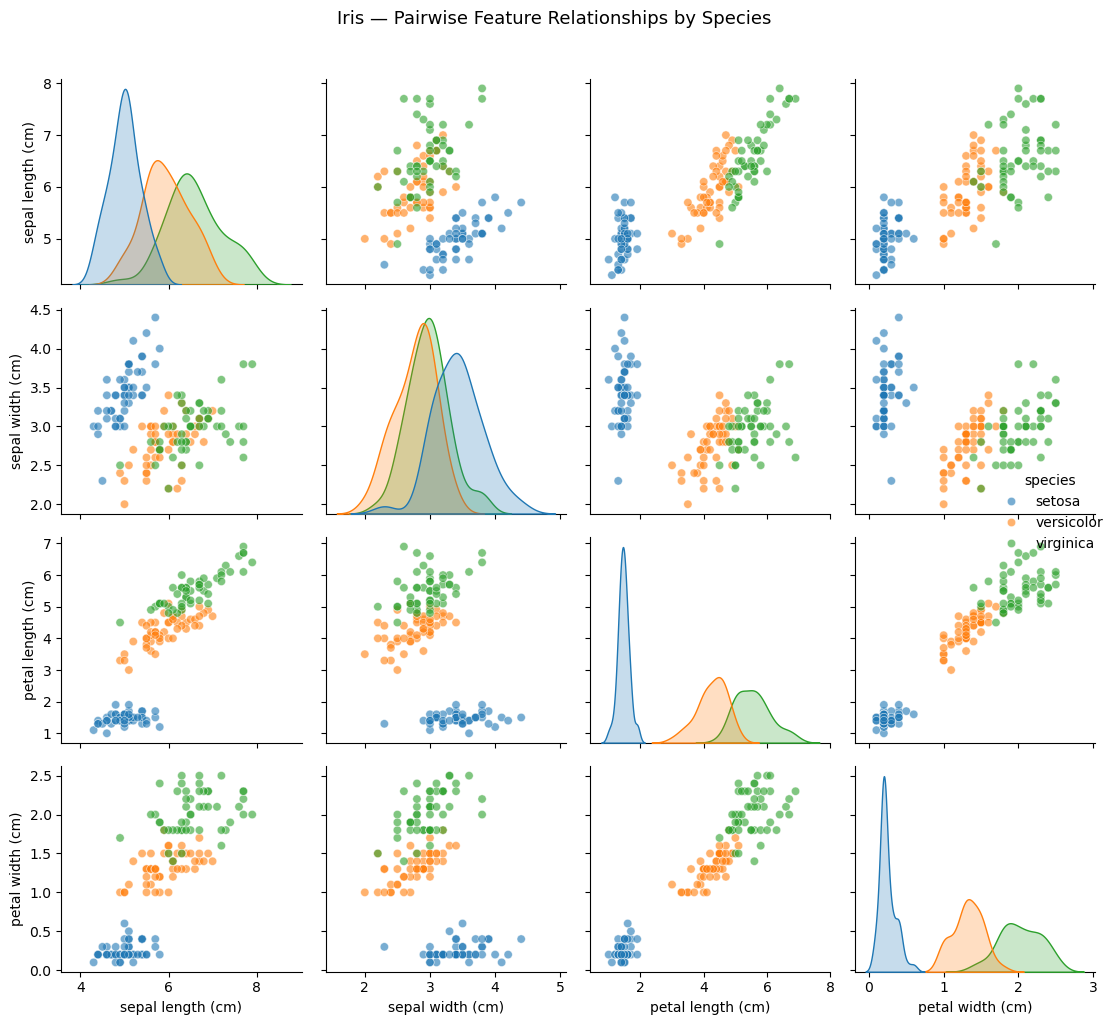

In [3]:
sns.pairplot(df.drop(columns='target'), hue='species',
             diag_kind='kde', plot_kws={'alpha': 0.6})
plt.suptitle('Iris — Pairwise Feature Relationships by Species', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

---

## 3. Train / Test Split

In [4]:
X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train : {X_train.shape[0]} samples')
print(f'Test  : {X_test.shape[0]} samples')

Train : 120 samples
Test  : 30 samples


---

## 4. Baseline Models

In [5]:
baselines = {
    'Decision Tree':       DecisionTreeClassifier(random_state=42),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=100, random_state=42)
}

print('Baseline Results')
print('-' * 55)
for name, model in baselines.items():
    model.fit(X_train, y_train)
    acc  = accuracy_score(y_test, model.predict(X_test))
    cv   = cross_val_score(model, X, y, cv=5, scoring='accuracy').mean()
    print(f'{name:<25}  Test Acc: {acc:.4f}   CV Acc: {cv:.4f}')

Baseline Results
-------------------------------------------------------
Decision Tree              Test Acc: 0.9333   CV Acc: 0.9533
Gradient Boosting          Test Acc: 0.9667   CV Acc: 0.9600


---

## 5. XGBoost Classifier

### 5.1 Training

For multi-class classification, XGBoost uses `objective='multi:softprob'` internally when the number of classes > 2. We set `eval_metric='mlogloss'` — multi-class log-loss — as the training evaluation metric.

In [6]:
xgb = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    use_label_encoder=False,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)
acc_xgb    = accuracy_score(y_test, y_pred_xgb)
cv_xgb     = cross_val_score(xgb, X, y, cv=5, scoring='accuracy').mean()

print(f'XGBoost  —  Train Acc: {xgb.score(X_train, y_train):.4f}   '
      f'Test Acc: {acc_xgb:.4f}   CV Acc: {cv_xgb:.4f}')

XGBoost  —  Train Acc: 1.0000   Test Acc: 0.9333   CV Acc: 0.9533


### 5.2 Confusion Matrix

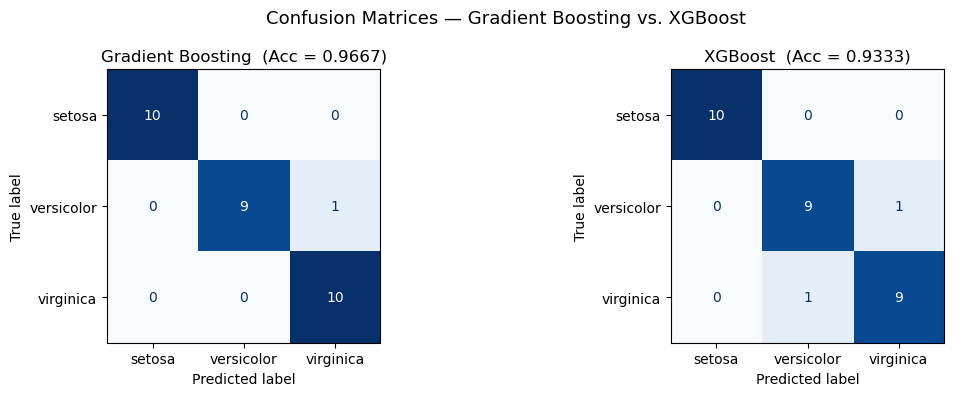

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, model, title in zip(
    axes,
    [baselines['Gradient Boosting'], xgb],
    ['Gradient Boosting', 'XGBoost']
):
    y_pred = model.predict(X_test)
    ConfusionMatrixDisplay(
        confusion_matrix(y_test, y_pred),
        display_labels=iris.target_names
    ).plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{title}  (Acc = {accuracy_score(y_test, y_pred):.4f})')

plt.suptitle('Confusion Matrices — Gradient Boosting vs. XGBoost', fontsize=13)
plt.tight_layout()
plt.show()

### 5.3 Classification Report

In [8]:
print('XGBoost — Classification Report')
print('=' * 50)
print(classification_report(y_test, y_pred_xgb, target_names=iris.target_names))

XGBoost — Classification Report
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



---

## 6. Feature Importances

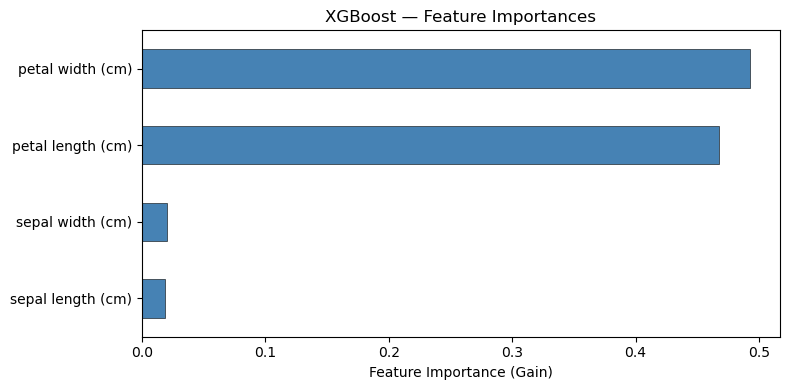


Feature Importances (ranked):
petal width (cm)     0.4923
petal length (cm)    0.4678
sepal width (cm)     0.0209
sepal length (cm)    0.0190


In [9]:
importances = pd.Series(
    xgb.feature_importances_,
    index=iris.feature_names
).sort_values(ascending=True)

plt.figure(figsize=(8, 4))
importances.plot(kind='barh', color='steelblue', edgecolor='k', linewidth=0.4)
plt.xlabel('Feature Importance (Gain)')
plt.title('XGBoost — Feature Importances')
plt.tight_layout()
plt.show()

print('\nFeature Importances (ranked):')
print(importances.sort_values(ascending=False).round(4).to_string())

---

## 7. Learning Curve — Accuracy vs. n_estimators

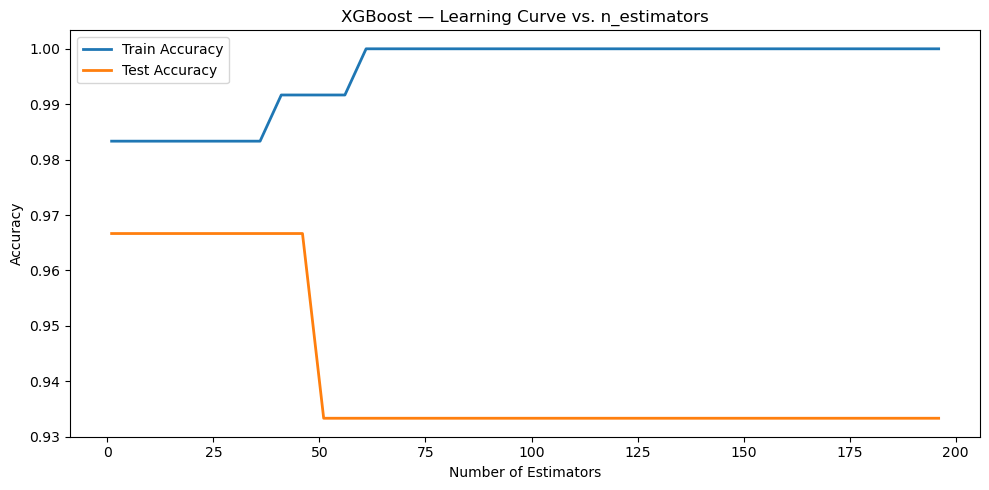

In [10]:
estimator_range = range(1, 201, 5)
train_scores, test_scores = [], []

for n in estimator_range:
    model = XGBClassifier(
        n_estimators=n, learning_rate=0.1, max_depth=4,
        use_label_encoder=False, eval_metric='mlogloss',
        random_state=42, n_jobs=-1
    )
    model.fit(X_train, y_train)
    train_scores.append(model.score(X_train, y_train))
    test_scores.append(accuracy_score(y_test, model.predict(X_test)))

plt.figure(figsize=(10, 5))
plt.plot(estimator_range, train_scores, lw=2, label='Train Accuracy')
plt.plot(estimator_range, test_scores,  lw=2, label='Test Accuracy')
plt.xlabel('Number of Estimators')
plt.ylabel('Accuracy')
plt.title('XGBoost — Learning Curve vs. n_estimators')
plt.legend()
plt.tight_layout()
plt.show()

---

## 8. Hyperparameter Tuning with GridSearchCV

In [11]:
%%time

param_grid = {
    'n_estimators':    [50, 100, 200],
    'learning_rate':   [0.01, 0.05, 0.1, 0.3],
    'max_depth':       [3, 4, 6],
    'subsample':       [0.8, 1.0],
    'colsample_bytree':[0.8, 1.0]
}

grid_search = GridSearchCV(
    XGBClassifier(
        use_label_encoder=False,
        eval_metric='mlogloss',
        random_state=42, n_jobs=-1
    ),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 144 candidates, totalling 720 fits
CPU times: total: 1.72 s
Wall time: 22.9 s


,estimator,"XGBClassifier...ree=None, ...)"
,param_grid,"{'colsample_bytree': [0.8, 1.0], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 4, ...], 'n_estimators': [50, 100, ...], ...}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,objective,'multi:softprob'


In [12]:
best = grid_search.best_estimator_
y_pred_tuned = best.predict(X_test)
acc_tuned    = accuracy_score(y_test, y_pred_tuned)
cv_tuned     = cross_val_score(best, X, y, cv=5, scoring='accuracy').mean()

print('Grid Search Results')
print('-' * 50)
print(f'CV Accuracy (best) : {grid_search.best_score_:.4f}')
print(f'Test Accuracy      : {acc_tuned:.4f}')
print(f'\nBest Parameters:')
for k, v in grid_search.best_params_.items():
    print(f'  {k:<22} {v}')

Grid Search Results
--------------------------------------------------
CV Accuracy (best) : 0.9583
Test Accuracy      : 0.9667

Best Parameters:
  colsample_bytree       0.8
  learning_rate          0.01
  max_depth              3
  n_estimators           200
  subsample              0.8


---

## 9. Results Summary

In [13]:
dt_acc = accuracy_score(y_test, baselines['Decision Tree'].predict(X_test))
gb_acc = accuracy_score(y_test, baselines['Gradient Boosting'].predict(X_test))
dt_cv  = cross_val_score(baselines['Decision Tree'], X, y, cv=5).mean()
gb_cv  = cross_val_score(baselines['Gradient Boosting'], X, y, cv=5).mean()

results = pd.DataFrame({
    'Model': [
        'Decision Tree',
        'Gradient Boosting (sklearn)',
        'XGBoost (n=100, lr=0.1)',
        'XGBoost (GridSearchCV)'
    ],
    'Test Accuracy': [round(dt_acc, 4), round(gb_acc, 4),
                      round(acc_xgb, 4), round(acc_tuned, 4)],
    'CV Accuracy':   [round(dt_cv, 4),  round(gb_cv, 4),
                      round(cv_xgb, 4), round(cv_tuned, 4)]
})

results = results.sort_values('Test Accuracy', ascending=False).reset_index(drop=True)
print(results.to_string(index=False))

                      Model  Test Accuracy  CV Accuracy
Gradient Boosting (sklearn)         0.9667       0.9600
     XGBoost (GridSearchCV)         0.9667       0.9467
              Decision Tree         0.9333       0.9533
    XGBoost (n=100, lr=0.1)         0.9333       0.9533


---

## Conclusion

This notebook applied `XGBClassifier` to the Iris dataset across a complete classification workflow.

**Key findings:**

- **XGBoost** matches or exceeds sklearn's `GradientBoostingClassifier` on this dataset while being faster to train due to its parallel tree construction and histogram-based splits.
- **Feature importances** confirm that `petal length` and `petal width` dominate — consistent with all classifiers evaluated in this series, validating XGBoost's importance scores as reliable feature selection signals.
- The **learning curve** shows that test accuracy stabilizes quickly on Iris (typically within 20–50 trees), with no significant overfitting as `n_estimators` grows — the regularization built into XGBoost keeps variance in check.
- **GridSearchCV** with `subsample` and `colsample_bytree` adds stochastic regularization, further preventing overfitting on this small dataset.
- The **confusion matrix** shows that versicolor and virginica remain the hardest classes to separate — a property consistent across every classifier in this series.

**Takeaways:**

- For multi-class problems, XGBoost uses `multi:softprob` internally — it outputs a probability vector per sample and takes the argmax. This means `predict_proba()` is available and useful for calibration.
- `subsample` and `colsample_bytree` are the most impactful regularization parameters in XGBoost — always include them in the grid search.
- On small datasets like Iris, XGBoost and Random Forest perform comparably. XGBoost's advantage is most pronounced on large, high-dimensional tabular datasets where its second-order gradients and regularization significantly improve generalization.
- **LightGBM** is an alternative to XGBoost that uses leaf-wise tree growth and histogram-based splits, offering faster training with similar or better accuracy on large datasets.